# Breast Cancer Survival Prediction Support Vector Machine (SVM)

**Dataset:** Breast Cancer survival dataset — 4,024 patients  
**Target:** `status` — *Alive (0)* or *Dead (1)*  
**Model:** Support Vector Machine with RBF Kernel

```

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      StratifiedKFold, cross_val_score,
                                      cross_val_predict)
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, accuracy_score, roc_curve,
    precision_score, recall_score, f1_score,
    log_loss, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import pointbiserialr, chi2_contingency
from collections import Counter

In [6]:
#Load Dataset & Basic Cleaning
df = pd.read_csv('../Dataset/Breast_Cancer.csv')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (4024, 16)
Columns: ['age', 'race', 'marital_status', 't_stage', 'n_stage', '6th_stage', 'differentiate', 'grade', 'a_stage', 'tumor_size', 'estrogen_status', 'progesterone_status', 'regional_node_examined', 'reginol_node_positive', 'survival_months', 'status']


,age,race,marital_status,t_stage,n_stage,6th_stage,differentiate,grade,a_stage,tumor_size,estrogen_status,progesterone_status,regional_node_examined,reginol_node_positive,survival_months,status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


### EDA

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   age                     4024 non-null   int64 
 1   race                    4024 non-null   object
 2   marital_status          4024 non-null   object
 3   t_stage                 4024 non-null   object
 4   n_stage                 4024 non-null   object
 5   6th_stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   grade                   4024 non-null   object
 8   a_stage                 4024 non-null   object
 9   tumor_size              4024 non-null   int64 
 10  estrogen_status         4024 non-null   object
 11  progesterone_status     4024 non-null   object
 12  regional_node_examined  4024 non-null   int64 
 13  reginol_node_positive   4024 non-null   int64 
 14  survival_months         4024 non-null   int64 
 15  stat

In [8]:
df.describe()

,age,tumor_size,regional_node_examined,reginol_node_positive,survival_months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [9]:
#no missing values

status
Alive    3408
Dead      616
Name: count, dtype: int64

Class proportions:
status
Alive    0.846918
Dead     0.153082
Name: proportion, dtype: float64


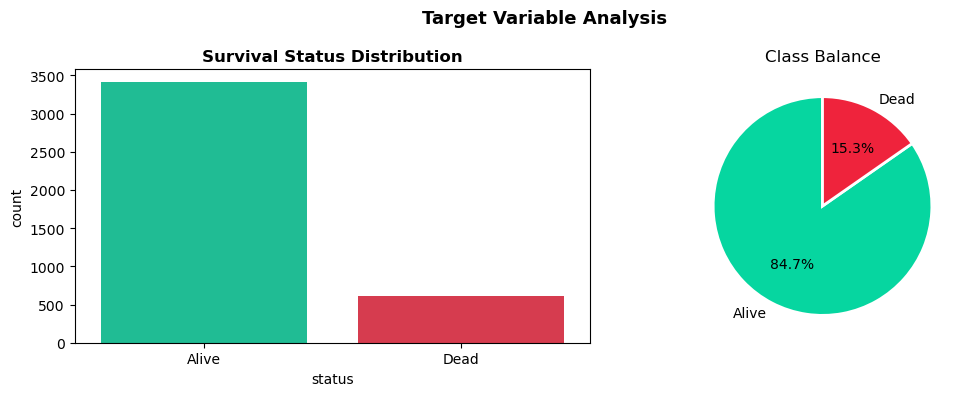

In [10]:
print(df['status'].value_counts())
print('\nClass proportions:')
print(df['status'].value_counts(normalize=True))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x=df['status'], palette=['#06d6a0', '#ef233c'], ax=axes[0])
axes[0].set_title('Survival Status Distribution', fontweight='bold')
counts = df['status'].value_counts()
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#06d6a0', '#ef233c'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Balance')
plt.suptitle('Target Variable Analysis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

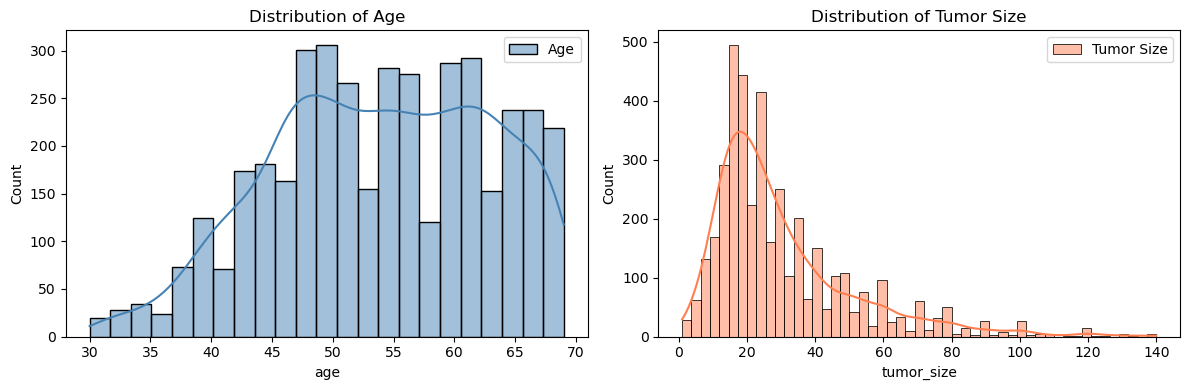

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['age'],        color='steelblue', kde=True, ax=axes[0], label='Age')
sns.histplot(df['tumor_size'], color='coral',     kde=True, ax=axes[1], label='Tumor Size')
axes[0].set_title('Distribution of Age');        axes[0].legend()
axes[1].set_title('Distribution of Tumor Size'); axes[1].legend()
plt.tight_layout(); plt.show()

### Drop Data-Leaking Feature

> `survival_months` records how long a patient survived after diagnosis — known only **after** the outcome. Including it hands the model the answer.

In [12]:
temp_status = (df['status'] == 'Dead').astype(int)
corr, p = pointbiserialr(temp_status, df['survival_months'])
print(f'Point-biserial r (Status vs survival_months): {corr:.3f},  p = {p:.2e}')
print('Strong correlation confirms post-outcome leakage — dropping.')
df = df.drop('survival_months', axis=1)
print(f'Remaining features: {df.shape[1] - 1} + target')

Point-biserial r (Status vs survival_months): -0.477,  p = 2.99e-227
Strong correlation confirms post-outcome leakage — dropping.
Remaining features: 14 + target


### Train / Test Split

> Split happens **first** — before feature engineering, encoding, or scaling.

In [13]:
X_raw = df.drop('status', axis=1)
y     = (df['status'] == 'Dead').astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train_raw.shape}  |  Test: {X_test_raw.shape}')
print('\nTrain class proportions:', y_train.value_counts(normalize=True).to_dict())
print('Test  class proportions:', y_test.value_counts(normalize=True).to_dict())

Train: (3219, 14)  |  Test: (805, 14)

Train class proportions: {0: 0.8468468468468469, 1: 0.15315315315315314}
Test  class proportions: {0: 0.8472049689440994, 1: 0.15279503105590062}


### Feature Engineering

| Feature | Source columns removed | Rationale |
|---|---|---|
| `stage_severity` | `t_stage`, `n_stage` | Combined T+N ordinal severity score |
| `lymph_node_burden` | kept raw cols too | Proportion of positive nodes |
| `grade_num` | `grade` | Ordinal 1-4 tumour grade |
| `hormone_positive_count` | `estrogen_status`, `progesterone_status` | Count of positive receptors (0-2) |
| `age_group` | — (`age` kept) | Clinical bins: <45, 45-60, >60 |
| `tumor_burden` | — | Tumor size x stage severity |
| `is_distant` | `a_stage` | Binary distant metastasis flag |
| `high_grade` | `differentiate` | Binary most-aggressive flag |

In [14]:
def engineer_features(df_in):
    """Engineer clinical features. Drops source columns to prevent multicollinearity."""
    df_out = df_in.copy()

    t_map     = {'T1': 1, 'T2': 2, 'T3': 3, 'T4': 4}
    n_map     = {'N1': 1, 'N2': 2, 'N3': 3}
    grade_map = {'1': 1, '2': 2, '3': 3, ' anaplastic; Grade IV': 4}

    df_out['stage_severity']         = df_out['t_stage'].map(t_map) + df_out['n_stage'].map(n_map)
    df_out['lymph_node_burden']      = df_out['reginol_node_positive'] / (df_out['regional_node_examined'] + 1)
    df_out['grade_num']              = df_out['grade'].map(grade_map)
    df_out['hormone_positive_count'] = (
        (df_out['estrogen_status'] == 'Positive').astype(int) +
        (df_out['progesterone_status'] == 'Positive').astype(int)
    )
    df_out['age_group']    = pd.cut(df_out['age'], bins=[0,45,60,100], labels=[0,1,2]).astype(int)
    df_out['tumor_burden'] = df_out['tumor_size'] * df_out['stage_severity']
    df_out['is_distant']   = (df_out['a_stage'] == 'Distant').astype(int)
    df_out['high_grade']   = df_out['differentiate'].isin(['Poorly differentiated','Undifferentiated']).astype(int)

    # Drop source cols to avoid multicollinearity
    source_cols = ['t_stage','n_stage','grade','a_stage','differentiate',
                   'estrogen_status','progesterone_status']
    df_out = df_out.drop(columns=source_cols)
    return df_out


X_train_eng = engineer_features(X_train_raw)
X_test_eng  = engineer_features(X_test_raw)

print(f'Shape after engineering: {X_train_eng.shape}')
print('Columns:', X_train_eng.columns.tolist())
X_train_eng.head()

Shape after engineering: (3219, 15)
Columns: ['age', 'race', 'marital_status', '6th_stage', 'tumor_size', 'regional_node_examined', 'reginol_node_positive', 'stage_severity', 'lymph_node_burden', 'grade_num', 'hormone_positive_count', 'age_group', 'tumor_burden', 'is_distant', 'high_grade']


,age,race,marital_status,6th_stage,tumor_size,regional_node_examined,reginol_node_positive,stage_severity,lymph_node_burden,grade_num,hormone_positive_count,age_group,tumor_burden,is_distant,high_grade
1909,50,White,Married,IIB,40,13,1,3,0.071429,1,2,1,120,0,0
1635,59,White,Married,IIA,12,11,2,2,0.166667,3,2,1,24,0,1
239,44,White,Married,IIA,11,8,2,2,0.222222,2,2,0,22,0,0
898,59,White,Divorced,IIIA,25,32,5,4,0.151515,2,1,1,100,0,0
2679,69,White,Married,IIA,18,4,1,2,0.200000,1,2,2,36,0,0


In [15]:
# Correlation check on training data only
new_features = ['stage_severity','lymph_node_burden','grade_num',
                'hormone_positive_count','age_group','tumor_burden','is_distant','high_grade']
rows = []
for feat in new_features:
    r, p = pointbiserialr(y_train.values, X_train_eng[feat].values)
    rows.append({'Feature': feat, 'r': round(r,3), 'p_value': f'{p:.2e}',
                 'Significant': 'Yes' if p < 0.05 else 'No'})
print('Point-biserial correlation with target (train only):')
print(pd.DataFrame(rows).sort_values('r', key=abs, ascending=False).to_string(index=False))

Point-biserial correlation with target (train only):
               Feature      r  p_value Significant
     lymph_node_burden  0.277 1.04e-57         Yes
        stage_severity  0.259 1.35e-50         Yes
hormone_positive_count -0.217 9.40e-36         Yes
          tumor_burden  0.187 1.33e-26         Yes
             grade_num  0.175 1.93e-23         Yes
            high_grade  0.171 1.85e-22         Yes
            is_distant  0.104 2.99e-09         Yes
             age_group  0.051 4.12e-03         Yes


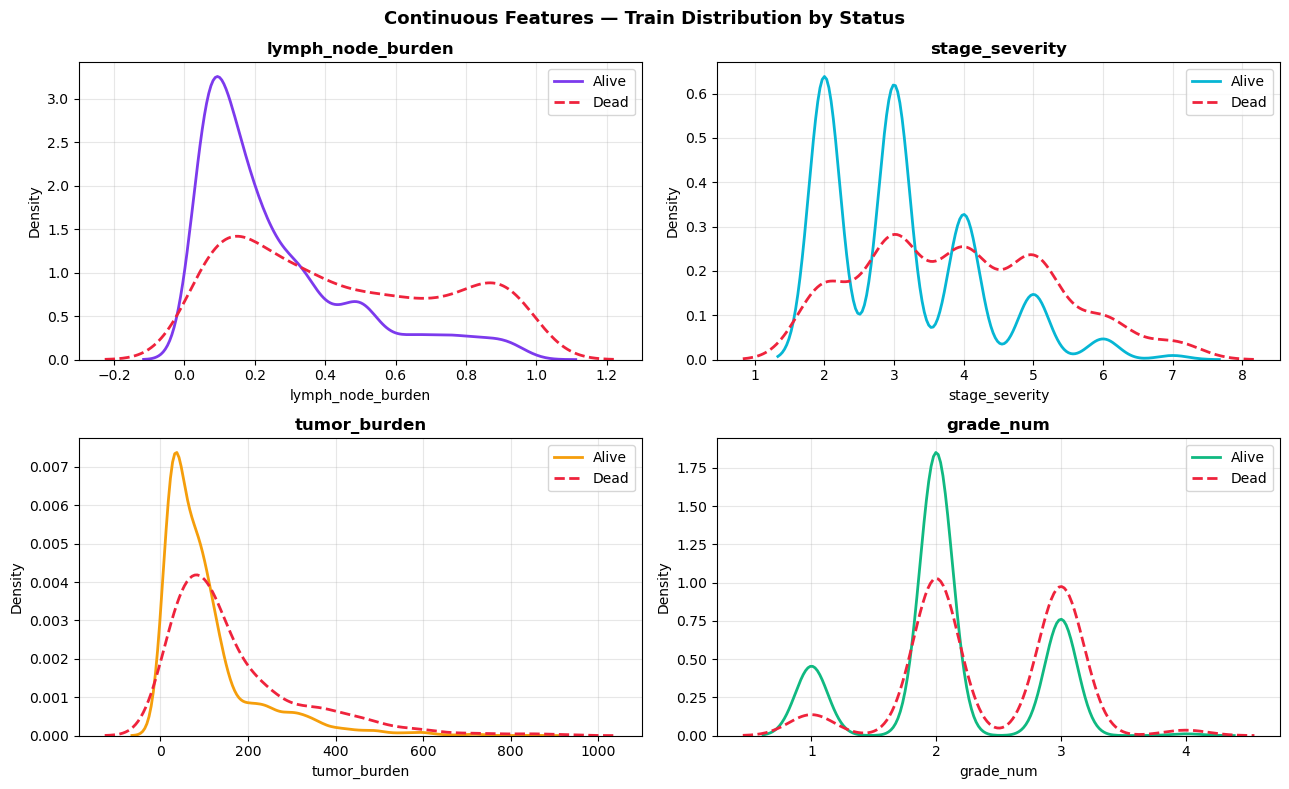

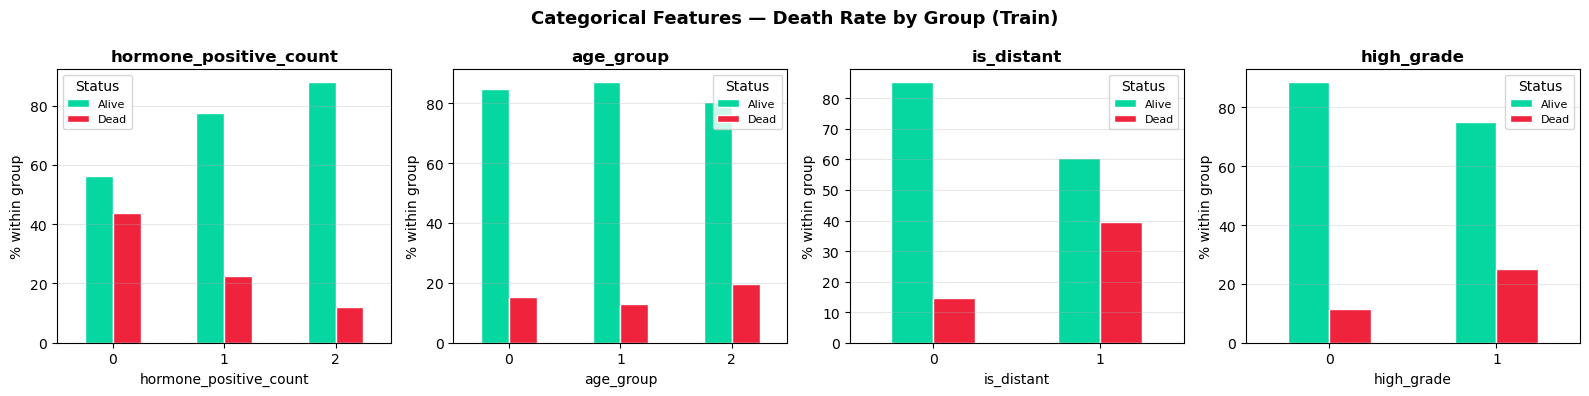

In [16]:
train_plot = X_train_eng.copy()
train_plot['status'] = y_train.map({0:'Alive',1:'Dead'}).values

# KDE plots for continuous engineered features
cont_feats = ['lymph_node_burden','stage_severity','tumor_burden','grade_num']
colors     = ['#7c3aed','#06b6d4','#f59e0b','#10b981']
fig, axes  = plt.subplots(2, 2, figsize=(13, 8))
for ax, feat, color in zip(axes.flatten(), cont_feats, colors):
    for status, ls in zip(['Alive','Dead'],['-','--']):
        c = color if status == 'Alive' else '#ef233c'
        sns.kdeplot(train_plot[train_plot['status']==status][feat],
                    ax=ax, label=status, linestyle=ls, color=c, linewidth=2)
    ax.set_title(feat, fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Continuous Features — Train Distribution by Status', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Bar charts for binary/count features
cat_eng = ['hormone_positive_count','age_group','is_distant','high_grade']
fig, axes = plt.subplots(1, 4, figsize=(16,4))
for ax, feat in zip(axes, cat_eng):
    ct = pd.crosstab(train_plot[feat], train_plot['status'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#06d6a0','#ef233c'], edgecolor='white', rot=0)
    ax.set_title(feat, fontweight='bold'); ax.set_ylabel('% within group')
    ax.legend(title='Status', fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.suptitle('Categorical Features — Death Rate by Group (Train)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### Outlier Detection & Capping

> SVM is sensitive to outliers. IQR method identifies outliers; values are **Winsorized** (capped at bounds) rather than removed to preserve sample size.  
> Bounds are computed on training data and applied to both train and test.

Feature                               Outliers   % of train
------------------------------------------------------------
age                                          0         0.0%
tumor_size                                 177         5.5%
regional_node_examined                      53         1.6%
reginol_node_positive                      270         8.4%
tumor_burden                               299         9.3%


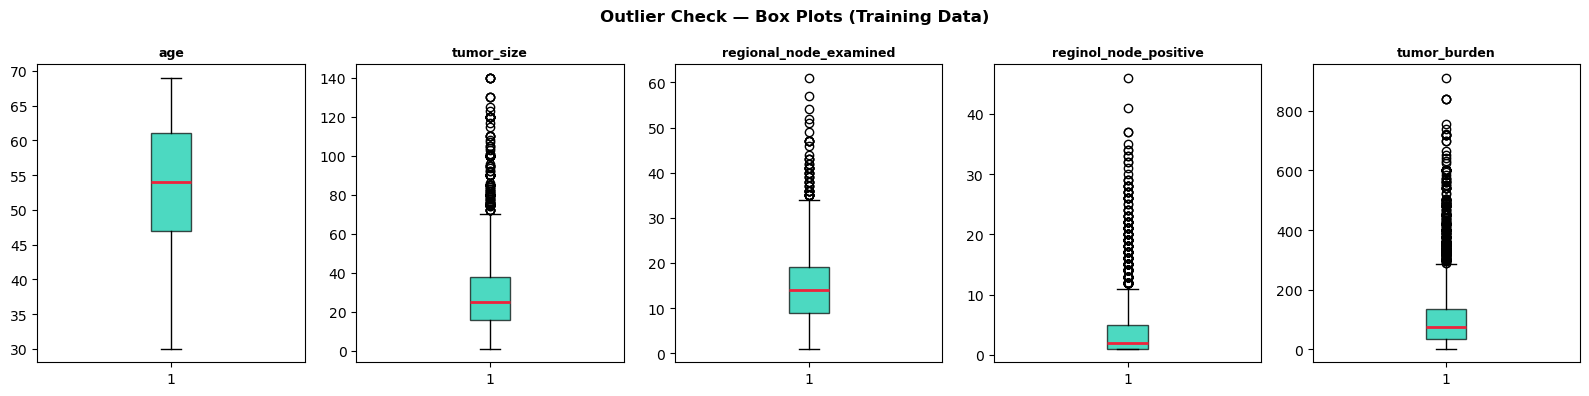

In [17]:
num_cols_check = ['age','tumor_size','regional_node_examined','reginol_node_positive','tumor_burden']

print(f'{"Feature":<35} {"Outliers":>10} {"% of train":>12}')
print('-' * 60)
for col in num_cols_check:
    Q1, Q3 = X_train_eng[col].quantile(0.25), X_train_eng[col].quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = ((X_train_eng[col] < Q1-1.5*IQR) | (X_train_eng[col] > Q3+1.5*IQR)).sum()
    print(f'{col:<35} {n_out:>10} {n_out/len(X_train_eng)*100:>11.1f}%')

fig, axes = plt.subplots(1, len(num_cols_check), figsize=(16, 4))
for ax, col in zip(axes, num_cols_check):
    ax.boxplot(X_train_eng[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#00c9a7', alpha=0.7),
               medianprops=dict(color='#ef233c', linewidth=2))
    ax.set_title(col, fontsize=9, fontweight='bold')
plt.suptitle('Outlier Check — Box Plots (Training Data)', fontweight='bold')
plt.tight_layout(); plt.show()

In [18]:
# Winsorize using bounds derived from training data
X_train_capped = X_train_eng.copy()
X_test_capped  = X_test_eng.copy()
cap_bounds     = {}

for col in num_cols_check:
    Q1, Q3    = X_train_eng[col].quantile(0.25), X_train_eng[col].quantile(0.75)
    IQR       = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    cap_bounds[col] = (lower, upper)
    X_train_capped[col] = X_train_eng[col].clip(lower, upper)
    X_test_capped[col]  = X_test_eng[col].clip(lower, upper)   # train bounds applied to test

print('Winsorization applied using training bounds')

Winsorization applied using training bounds


###Encoding

###Illustrate All Encoding Types

In [19]:
cat_cols_remaining = ['race','marital_status','6th_stage']

ohe_df   = pd.get_dummies(X_train_capped, columns=cat_cols_remaining)
dummy_df = pd.get_dummies(X_train_capped, columns=cat_cols_remaining, drop_first=True)
print(f'One-hot shape: {ohe_df.shape}')
print(f'Dummy shape  : {dummy_df.shape}')

One-hot shape: (3219, 25)
Dummy shape  : (3219, 22)


###Label Encoding Fit on Train Only

In [20]:
X_train_enc = X_train_capped.copy()
X_test_enc  = X_test_capped.copy()
encoders    = {}

for col in cat_cols_remaining:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train_capped[col])
    X_test_enc[col]  = le.transform(X_test_capped[col])
    encoders[col]    = le
    print(f'  {col}: {list(le.classes_)}')

print('\nLabel encoding complete (fit on train only)')

  race: ['Black', 'Other', 'White']
  marital_status: ['Divorced', 'Married', 'Separated', 'Single ', 'Widowed']
  6th_stage: ['IIA', 'IIB', 'IIIA', 'IIIB', 'IIIC']

Label encoding complete (fit on train only)


###Feature Scaling Fit on Original Train

> StandardScaler fitted on **original `X_train`** (before SMOTE). SVM is distance-based, scaling is mandatory.

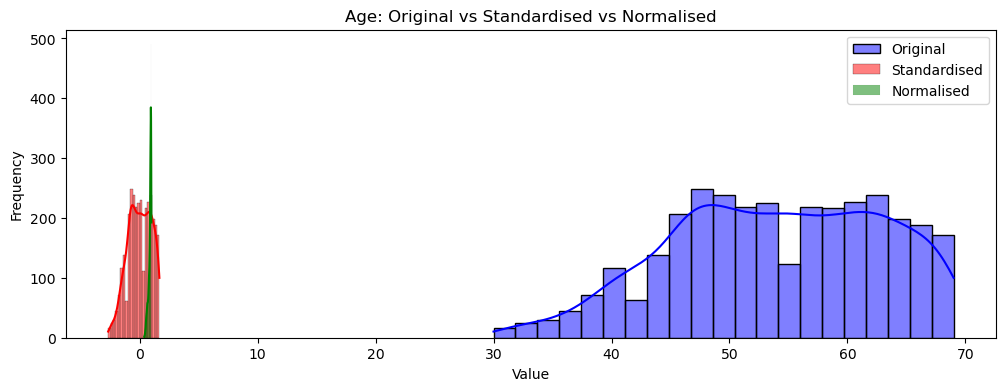

Scaling done.  Train: (3219, 15)  |  Test: (805, 15)


In [21]:
# Illustrate: original vs standardised vs normalised
s_x = X_train_enc[['age','tumor_size','stage_severity','lymph_node_burden']]
std_vals  = preprocessing.StandardScaler().fit_transform(s_x)
norm_vals = preprocessing.Normalizer().fit_transform(s_x)

plt.figure(figsize=(12,4))
sns.histplot(s_x['age'],     color='blue',  label='Original',     kde=True, alpha=0.5)
sns.histplot(std_vals[:,0],  color='red',   label='Standardised', kde=True, alpha=0.5)
sns.histplot(norm_vals[:,0], color='green', label='Normalised',   kde=True, alpha=0.5)
plt.title('Age: Original vs Standardised vs Normalised')
plt.xlabel('Value'); plt.ylabel('Frequency'); plt.legend()
plt.show()

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_enc)
X_test_sc  = scaler.transform(X_test_enc)
X_train_sc_df = pd.DataFrame(X_train_sc, columns=X_train_enc.columns)
X_test_sc_df  = pd.DataFrame(X_test_sc,  columns=X_test_enc.columns)

print(f'Scaling done.  Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}')

### Feature Selection

### Filter Pearson Correlation (numerical only)

                         age  tumor_size  regional_node_examined  \
age                     1.00       -0.10                   -0.04   
tumor_size             -0.10        1.00                    0.11   
regional_node_examined -0.04        0.11                    1.00   
reginol_node_positive   0.01        0.31                    0.36   
stage_severity         -0.05        0.73                    0.26   
lymph_node_burden       0.04        0.26                   -0.11   
grade_num              -0.10        0.13                    0.07   
tumor_burden           -0.08        0.96                    0.16   

                        reginol_node_positive  stage_severity  \
age                                      0.01           -0.05   
tumor_size                               0.31            0.73   
regional_node_examined                   0.36            0.26   
reginol_node_positive                    1.00            0.74   
stage_severity                           0.74            1.00 

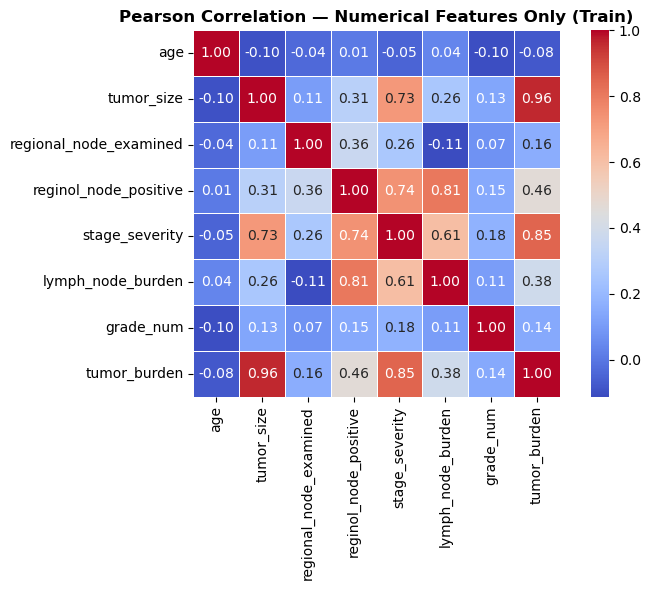

In [22]:
num_cols_corr = ['age','tumor_size','regional_node_examined','reginol_node_positive',
                 'stage_severity','lymph_node_burden','grade_num','tumor_burden']
corr_mat = X_train_enc[num_cols_corr].corr()
print(round(corr_mat, 2))

plt.figure(figsize=(8,6))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Pearson Correlation — Numerical Features Only (Train)', fontweight='bold')
plt.tight_layout(); plt.show()

### Filter Chi-Square on Training Data Only

In [23]:
train_chi2_df = X_train_enc.copy()
train_chi2_df['status'] = y_train.values

print('Chi-Square: Categorical Features vs Status (Training Data Only)\n')
print(f'{"Feature":<25} {"Chi2":>10} {"p-value":>12} {"Significant?":>14}')
print('-' * 65)
for col in cat_cols_remaining:
    ct = pd.crosstab(train_chi2_df[col], train_chi2_df['status'])
    c2, p, _, _ = chi2_contingency(ct)
    print(f'{col:<25} {c2:>10.2f} {p:>12.4f} {"Yes" if p<0.05 else "No":>14}')

Chi-Square: Categorical Features vs Status (Training Data Only)

Feature                         Chi2      p-value   Significant?
-----------------------------------------------------------------
race                           21.74       0.0000            Yes
marital_status                 27.89       0.0000            Yes
6th_stage                     231.02       0.0000            Yes


### Wrapper RFE on Training Data Only

In [24]:
print('Before SMOTE (for RFE):', Counter(y_train))
X_train_sm_rfe, y_train_sm_rfe = SMOTE(random_state=42).fit_resample(X_train_sc, y_train)
print('After  SMOTE (for RFE):', Counter(y_train_sm_rfe))

Before SMOTE (for RFE): Counter({0: 2726, 1: 493})
After  SMOTE (for RFE): Counter({0: 2726, 1: 2726})


In [25]:
rfe = RFE(SVC(kernel='linear', C=1.0, class_weight='balanced'), n_features_to_select=10)
rfe.fit(X_train_sm_rfe, y_train_sm_rfe)

selected_features = list(X_train_enc.columns[rfe.support_])
rfe_df = pd.DataFrame({'Feature': X_train_enc.columns,
                        'Selected': rfe.support_,
                        'Rank': rfe.ranking_}).sort_values('Rank')
print(rfe_df.to_string(index=False))
print(f'\nSelected {len(selected_features)} features: {selected_features}')

               Feature  Selected  Rank
                  race      True     1
        marital_status      True     1
             6th_stage      True     1
            tumor_size      True     1
        stage_severity      True     1
     lymph_node_burden      True     1
             grade_num      True     1
hormone_positive_count      True     1
             age_group      True     1
          tumor_burden      True     1
            high_grade     False     2
                   age     False     3
regional_node_examined     False     4
 reginol_node_positive     False     5
            is_distant     False     6

Selected 10 features: ['race', 'marital_status', '6th_stage', 'tumor_size', 'stage_severity', 'lymph_node_burden', 'grade_num', 'hormone_positive_count', 'age_group', 'tumor_burden']


### Embedded LASSO on Original (Non-SMOTE) Train

> LASSO uses original training data, SMOTE is for model training, not analytical feature selection.

In [26]:
lr_plain = LogisticRegression(max_iter=1000)
lr_plain.fit(X_train_sc, y_train)
print(f'LR (plain) Train: {lr_plain.score(X_train_sc, y_train):.4f}  Test: {lr_plain.score(X_test_sc, y_test):.4f}')

"""
C = 1/alpha. solver='liblinear' required for L1.
Features with coef=0 are excluded by regularisation.
"""
lr_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=1)
lr_lasso.fit(X_train_sc, y_train)   # original non-SMOTE train
print(f'LR LASSO   Train: {lr_lasso.score(X_train_sc, y_train):.4f}  Test: {lr_lasso.score(X_test_sc, y_test):.4f}')

LR (plain) Train: 0.8571  Test: 0.8522
LR LASSO   Train: 0.8590  Test: 0.8547


In [27]:
odds_pct = (np.exp(lr_lasso.coef_) - 1) * 100
print('LASSO Non-zero Coefficients:\n')
print(f'{"Feature":<35} {"Coefficient":>12} {"Odds Ratio %":>14}')
print('-' * 63)
for feat, coef, orp in zip(X_train_enc.columns, lr_lasso.coef_[0], odds_pct[0]):
    if coef != 0:
        print(f'{feat:<35} {coef:>12.4f} {orp:>14.2f}%')

LASSO Non-zero Coefficients:

Feature                              Coefficient   Odds Ratio %
---------------------------------------------------------------
age                                       0.0167           1.68%
race                                     -0.0921          -8.80%
marital_status                            0.0695           7.20%
tumor_size                                0.0507           5.20%
regional_node_examined                    0.0522           5.36%
reginol_node_positive                    -0.2620         -23.05%
stage_severity                            0.5084          66.27%
lymph_node_burden                         0.5587          74.84%
grade_num                                 0.3246          38.35%
hormone_positive_count                   -0.3671         -30.73%
age_group                                 0.1907          21.01%
tumor_burden                             -0.1575         -14.58%
is_distant                                0.0163           1.6

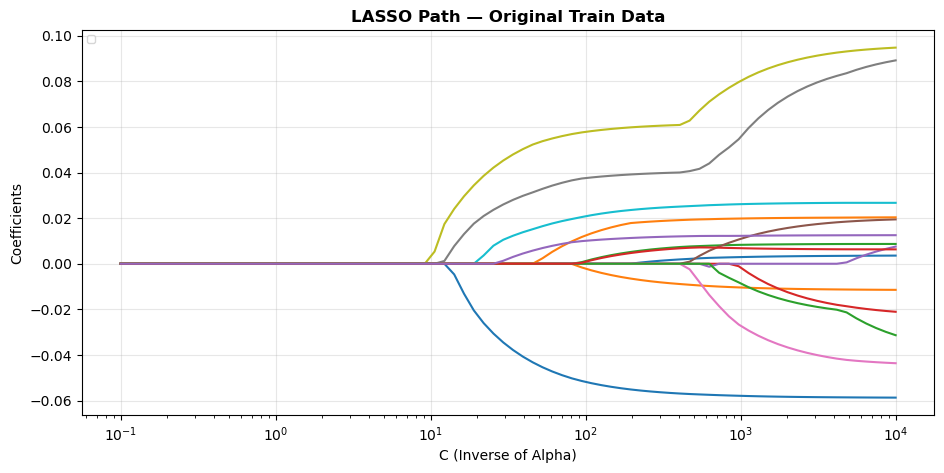

In [28]:
from sklearn.linear_model import lasso_path

alphas = np.logspace(-4, 1, 80)
alphas_path, coefs_path, _ = lasso_path(X_train_sc, y_train, alphas=alphas)
Cs = 1.0 / alphas_path

plt.figure(figsize=(11, 5))
for i in range(coefs_path.shape[0]):
    lbl = X_train_enc.columns[i] if abs(coefs_path[i]).max() > 0.1 else '_nolegend_'
    plt.plot(Cs, coefs_path[i], label=lbl)
plt.xlabel('C (Inverse of Alpha)'); plt.ylabel('Coefficients')
plt.title('LASSO Path — Original Train Data', fontweight='bold')
plt.xscale('log'); plt.legend(loc='upper left', fontsize=7, ncol=2)
plt.grid(alpha=0.3); plt.show()

## Apply RFE-Selected Features

> Final model trains **only on RFE-selected features**.

In [29]:
X_train_rfe = X_train_sc_df[selected_features].values
X_test_rfe  = X_test_sc_df[selected_features].values
print(f'Features used in model: {selected_features}')
print(f'Train: {X_train_rfe.shape}  |  Test: {X_test_rfe.shape}')

Features used in model: ['race', 'marital_status', '6th_stage', 'tumor_size', 'stage_severity', 'lymph_node_burden', 'grade_num', 'hormone_positive_count', 'age_group', 'tumor_burden']
Train: (3219, 10)  |  Test: (805, 10)


### Class Imbalance — SMOTE inside Pipeline

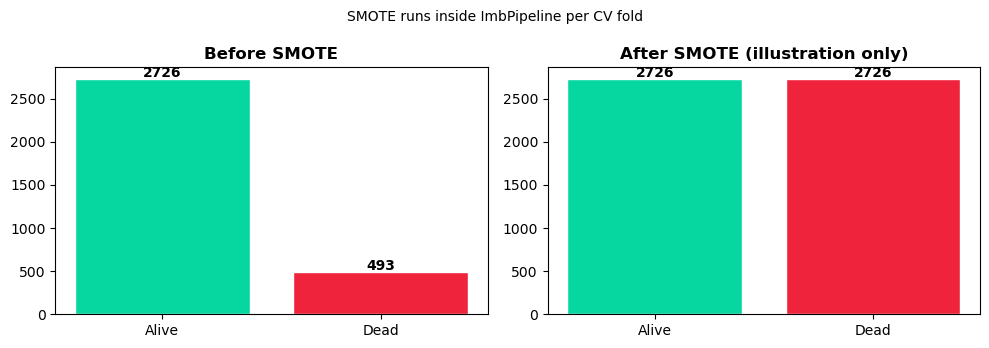

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
before = Counter(y_train)
bars  = axes[0].bar(['Alive','Dead'], [before[0],before[1]], color=['#06d6a0','#ef233c'], edgecolor='white')
axes[0].set_title('Before SMOTE', fontweight='bold')
for b, v in zip(bars,[before[0],before[1]]):
    axes[0].text(b.get_x()+b.get_width()/2, v+20, str(v), ha='center', fontweight='bold')

_, y_demo = SMOTE(random_state=42).fit_resample(X_train_rfe, y_train)
after = Counter(y_demo)
bars2 = axes[1].bar(['Alive','Dead'], [after[0],after[1]], color=['#06d6a0','#ef233c'], edgecolor='white')
axes[1].set_title('After SMOTE (illustration only)', fontweight='bold')
for b, v in zip(bars2,[after[0],after[1]]):
    axes[1].text(b.get_x()+b.get_width()/2, v+20, str(v), ha='center', fontweight='bold')

plt.suptitle('SMOTE runs inside ImbPipeline per CV fold', fontsize=10)
plt.tight_layout(); plt.show()

### Baseline Model

=== Baseline SVM (C=1.0) ===
Train accuracy: 75.12%
Test  accuracy: 69.94%
              precision    recall  f1-score   support

       Alive       0.91      0.72      0.80       682
        Dead       0.27      0.59      0.37       123

    accuracy                           0.70       805
   macro avg       0.59      0.65      0.59       805
weighted avg       0.81      0.70      0.74       805



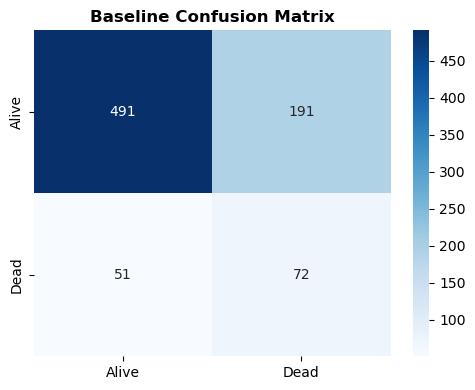

In [31]:
baseline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('svm',   SVC(kernel='rbf', C=1.0, gamma='scale', probability=True,
                  class_weight='balanced', random_state=42))
])
baseline.fit(X_train_rfe, y_train)
y_pred_base = baseline.predict(X_test_rfe)

print('=== Baseline SVM (C=1.0) ===')
print(f'Train accuracy: {baseline.score(X_train_rfe, y_train)*100:.2f}%')
print(f'Test  accuracy: {accuracy_score(y_test, y_pred_base)*100:.2f}%')
print(classification_report(y_test, y_pred_base, target_names=['Alive','Dead']))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_base), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Alive','Dead'], yticklabels=['Alive','Dead'])
plt.title('Baseline Confusion Matrix', fontweight='bold'); plt.tight_layout(); plt.show()

### Hyperparameter Tuning — GridSearchCV

In [32]:
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('svm',   SVC(probability=True, class_weight='balanced', random_state=42))
])

param_grid = {
    'svm__C'     : [0.1, 1.0, 10.0],
    'svm__gamma' : ['scale', 'auto'],
    'svm__kernel': ['rbf', 'sigmoid']
}

cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipeline, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
grid.fit(X_train_rfe, y_train)

print(f'\nBest parameters : {grid.best_params_}')
print(f'Best CV ROC-AUC : {grid.best_score_:.4f}')

best_model       = grid.best_estimator_
best_svm_params  = {k.replace('svm__',''):v for k,v in grid.best_params_.items()}

print(f'\nTrain accuracy: {best_model.score(X_train_rfe, y_train)*100:.2f}%')
print(f'Test  accuracy: {accuracy_score(y_test, best_model.predict(X_test_rfe))*100:.2f}%')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters : {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV ROC-AUC : 0.7488

Train accuracy: 72.04%
Test  accuracy: 67.83%


### Threshold Tuning — via Cross-Validation

> The optimal threshold is found on these Out Of Fold predictions — **not** on the test set.  
> The chosen threshold is then applied **once** to the test set.

In [33]:
tuned_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('svm',   SVC(**best_svm_params, probability=True, class_weight='balanced', random_state=42))
])

# Out-of-fold probabilities on training set
cv_probs = cross_val_predict(
    tuned_pipeline, X_train_rfe, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict_proba'
)[:, 1]

best_t, best_f1_cv = 0.5, 0
print(f"{'Threshold':>10} | {'Recall (Dead)':>13} | {'Precision (Dead)':>16} | {'F1 (Dead)':>10}")
print('-' * 58)
for t in np.arange(0.10, 0.90, 0.05):
    y_t   = (cv_probs >= t).astype(int)
    rec   = recall_score(y_train,    y_t, pos_label=1, zero_division=0)
    prec  = precision_score(y_train, y_t, pos_label=1, zero_division=0)
    f1_t  = f1_score(y_train,        y_t, pos_label=1, zero_division=0)
    print(f"{t:>10.2f} | {rec:>13.4f} | {prec:>16.4f} | {f1_t:>10.4f}")
    if f1_t > best_f1_cv:
        best_f1_cv, best_t = f1_t, t

print(f'\nBest threshold (CV train): {best_t:.2f}')
print(f'Best CV F1 (Dead): {best_f1_cv:.4f}')

 Threshold | Recall (Dead) | Precision (Dead) |  F1 (Dead)
----------------------------------------------------------
      0.10 |        1.0000 |           0.1532 |     0.2656
      0.15 |        0.9838 |           0.1599 |     0.2750
      0.20 |        0.9533 |           0.1820 |     0.3057
      0.25 |        0.8986 |           0.2124 |     0.3435
      0.30 |        0.8337 |           0.2267 |     0.3565
      0.35 |        0.7911 |           0.2459 |     0.3752
      0.40 |        0.7343 |           0.2595 |     0.3835
      0.45 |        0.6978 |           0.2794 |     0.3991
      0.50 |        0.6491 |           0.2996 |     0.4100
      0.55 |        0.6166 |           0.3128 |     0.4150
      0.60 |        0.5558 |           0.3231 |     0.4087
      0.65 |        0.5071 |           0.3411 |     0.4078
      0.70 |        0.4564 |           0.3940 |     0.4229
      0.75 |        0.3327 |           0.4131 |     0.3685
      0.80 |        0.1521 |           0.4144 |     0.22

In [34]:
# Apply threshold ONCE to test set
y_prob         = best_model.predict_proba(X_test_rfe)[:, 1]
BEST_THRESHOLD = best_t
y_pred_final   = (y_prob >= BEST_THRESHOLD).astype(int)

print(f'Threshold applied: {BEST_THRESHOLD:.2f}')
print(f'Test Accuracy: {accuracy_score(y_test, y_pred_final):.4f}')
print()
print(classification_report(y_test, y_pred_final, target_names=['Alive','Dead']))

Threshold applied: 0.70
Test Accuracy: 0.7938

              precision    recall  f1-score   support

       Alive       0.90      0.86      0.88       682
        Dead       0.36      0.45      0.40       123

    accuracy                           0.79       805
   macro avg       0.63      0.65      0.64       805
weighted avg       0.81      0.79      0.80       805



### Model Evaluation

In [35]:
acc  = accuracy_score(y_test, y_pred_final)
auc  = roc_auc_score(y_test, y_prob)
prec = precision_score(y_test, y_pred_final, pos_label=1, zero_division=0)
rec  = recall_score(y_test, y_pred_final, pos_label=1)
f1   = f1_score(y_test, y_pred_final, pos_label=1)
ll   = log_loss(y_test, y_prob)
ap   = average_precision_score(y_test, y_prob)

print('=' * 50)
print('        SVM MODEL PERFORMANCE SUMMARY')
print('=' * 50)
print(f'  Accuracy              : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  ROC-AUC               : {auc:.4f}')
print(f'  Average Precision     : {ap:.4f}')
print(f'  Log Loss              : {ll:.4f}')
print(f'  Precision (Dead)      : {prec:.4f}')
print(f'  Recall    (Dead)      : {rec:.4f}')
print(f'  F1-Score  (Dead)      : {f1:.4f}')
print('=' * 50)

        SVM MODEL PERFORMANCE SUMMARY
  Accuracy              : 0.7938  (79.38%)
  ROC-AUC               : 0.7186
  Average Precision     : 0.3243
  Log Loss              : 0.6122
  Precision (Dead)      : 0.3595
  Recall    (Dead)      : 0.4472
  F1-Score  (Dead)      : 0.3986


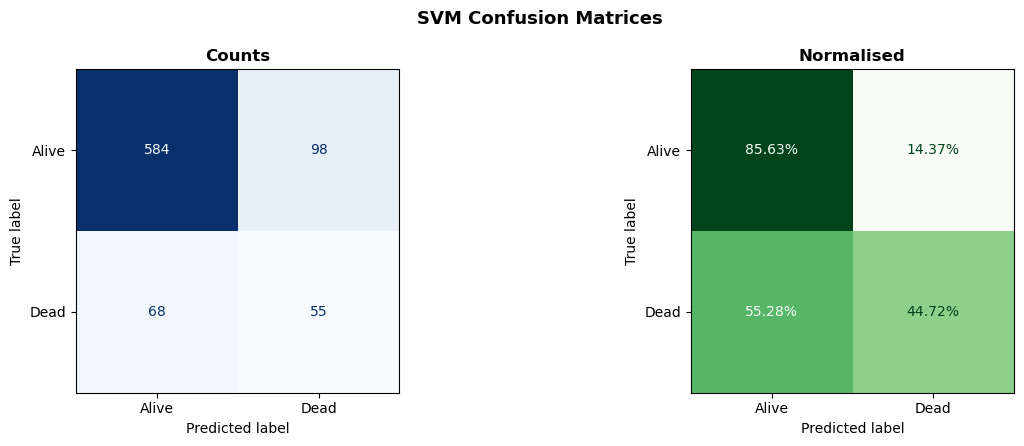

In [36]:
cm = confusion_matrix(y_test, y_pred_final)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ConfusionMatrixDisplay(cm, display_labels=['Alive','Dead']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Counts', fontweight='bold')
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=['Alive','Dead']).plot(ax=axes[1], colorbar=False, cmap='Greens', values_format='.2%')
axes[1].set_title('Normalised', fontweight='bold')
plt.suptitle('SVM Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

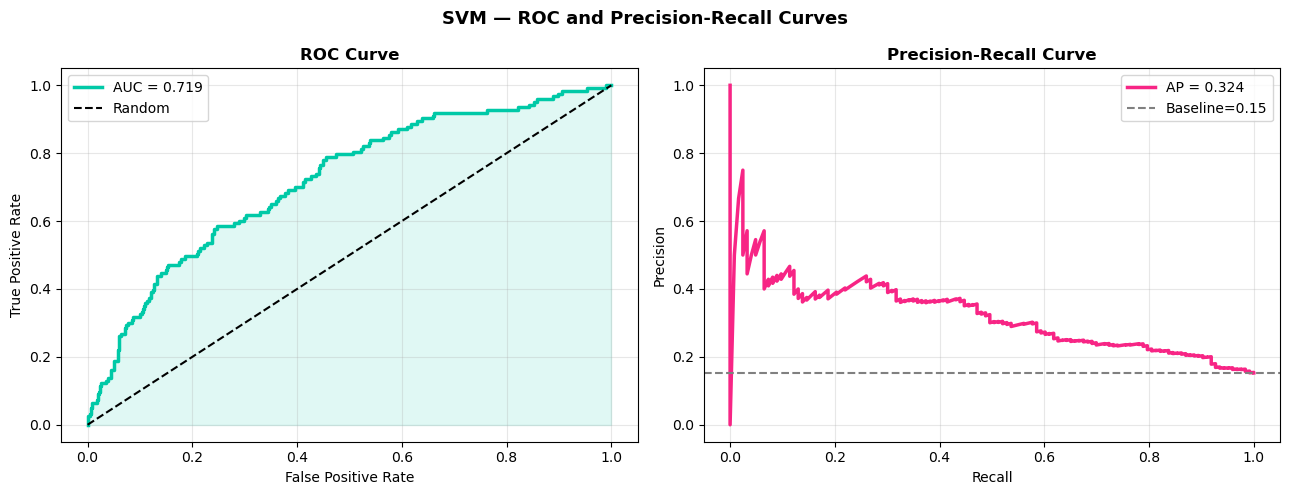

In [37]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color='#00c9a7', lw=2.5, label=f'AUC = {auc:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1.5, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.12, color='#00c9a7')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)

prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(rec_vals, prec_vals, color='#f72585', lw=2.5, label=f'AP = {ap:.3f}')
axes[1].axhline(y_test.mean(), color='gray', ls='--', lw=1.5, label=f'Baseline={y_test.mean():.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('SVM — ROC and Precision-Recall Curves', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

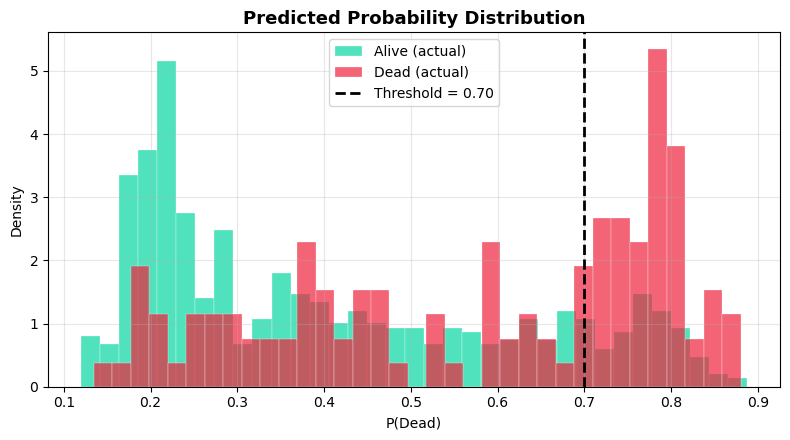

In [38]:
plt.figure(figsize=(8, 4.5))
plt.hist(y_prob[y_test==0], bins=35, alpha=0.70, color='#06d6a0', label='Alive (actual)', density=True, edgecolor='white', lw=0.3)
plt.hist(y_prob[y_test==1], bins=35, alpha=0.70, color='#ef233c', label='Dead (actual)',  density=True, edgecolor='white', lw=0.3)
plt.axvline(BEST_THRESHOLD, color='black', ls='--', lw=2, label=f'Threshold = {BEST_THRESHOLD:.2f}')
plt.xlabel('P(Dead)'); plt.ylabel('Density')
plt.title('Predicted Probability Distribution', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Feature Importance — Permutation Importance

>  SMOTE must never touch test data.

In [39]:
# Fit standalone SVM with best params on SMOTE-balanced train
X_sm_final, y_sm_final = SMOTE(random_state=42).fit_resample(X_train_rfe, y_train)
svm_for_perm = SVC(**best_svm_params, probability=True, class_weight='balanced', random_state=42)
svm_for_perm.fit(X_sm_final, y_sm_final)

print(f'Standalone SVM test accuracy: {accuracy_score(y_test, svm_for_perm.predict(X_test_rfe))*100:.2f}%')

Standalone SVM test accuracy: 67.83%


In [40]:
perm = permutation_importance(
    svm_for_perm, X_test_rfe, y_test,
    n_repeats=15, random_state=42, scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'Feature'    : selected_features,
    'Importance' : perm.importances_mean,
    'Std'        : perm.importances_std
}).sort_values('Importance', ascending=False)

print('Permutation Importances (ROC-AUC drop when feature shuffled):')
print(perm_df.to_string(index=False))

Permutation Importances (ROC-AUC drop when feature shuffled):
               Feature  Importance      Std
     lymph_node_burden    0.035181 0.005993
             age_group    0.026803 0.008387
        stage_severity    0.018586 0.009742
hormone_positive_count    0.014979 0.006673
                  race    0.011044 0.004567
             grade_num    0.007650 0.010677
            tumor_size    0.007377 0.003646
          tumor_burden    0.005402 0.003992
        marital_status    0.005179 0.005790
             6th_stage    0.005133 0.005070


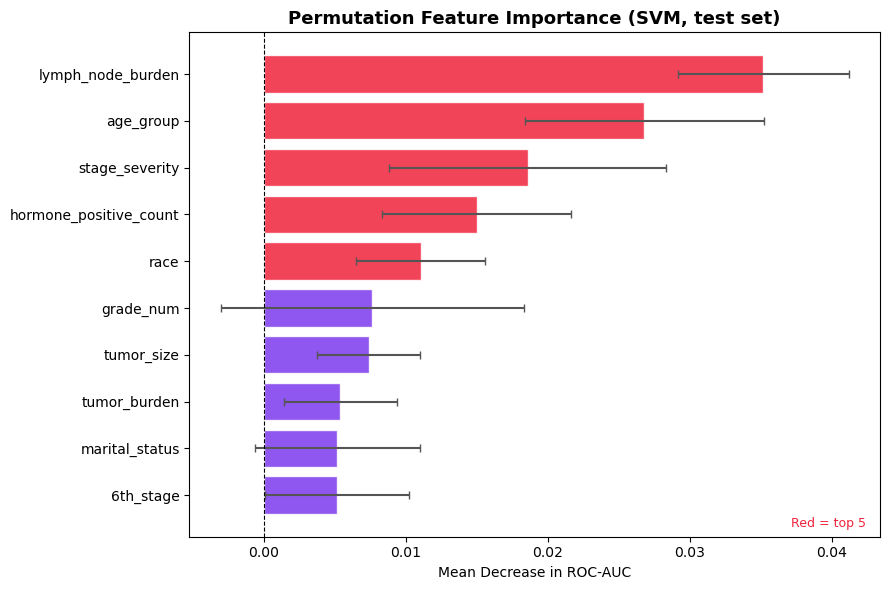

In [41]:
sorted_df = perm_df.sort_values('Importance', ascending=True)
colors_pi = ['#ef233c' if i >= len(sorted_df)-5 else '#7c3aed' for i in range(len(sorted_df))]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(sorted_df['Feature'], sorted_df['Importance'],
        xerr=sorted_df['Std'], color=colors_pi, alpha=0.85,
        error_kw={'elinewidth':1.5,'ecolor':'#555','capsize':3}, edgecolor='white')
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Mean Decrease in ROC-AUC')
ax.set_title('Permutation Feature Importance (SVM, test set)', fontsize=13, fontweight='bold')
ax.annotate('Red = top 5', xy=(0.98,0.02), xycoords='axes fraction', ha='right', fontsize=9, color='#ef233c')
plt.tight_layout(); plt.show()

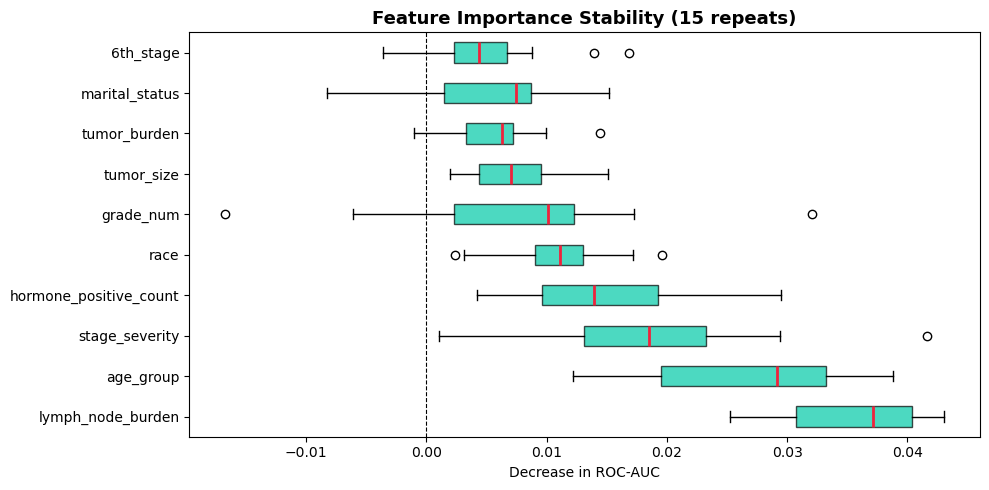

In [42]:
top10_names = perm_df.head(10)['Feature'].tolist()
top10_idx   = [selected_features.index(f) for f in top10_names]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(perm.importances[top10_idx].T, vert=False, labels=top10_names,
           patch_artist=True,
           boxprops=dict(facecolor='#00c9a7', alpha=0.7),
           medianprops=dict(color='#ef233c', linewidth=2))
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Decrease in ROC-AUC')
ax.set_title('Feature Importance Stability (15 repeats)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### ross-Validation Tuned Pipeline

> CV uses the **tuned pipeline** with best params from GridSearch, not the default-param pipeline.

5-Fold CV ROC-AUC (tuned params, SMOTE per fold):
  Fold 1: 0.7359
  Fold 2: 0.7538
  Fold 3: 0.7213
  Fold 4: 0.7626
  Fold 5: 0.7706

  Mean : 0.7488
  Std  : 0.0180


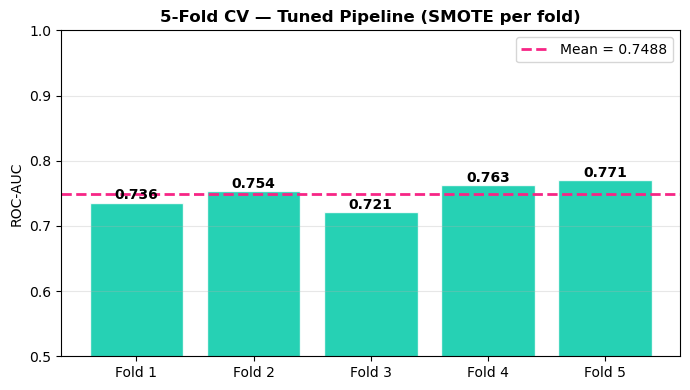

In [43]:
cv_scores = cross_val_score(
    tuned_pipeline, X_train_rfe, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)

print('5-Fold CV ROC-AUC (tuned params, SMOTE per fold):')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'\n  Mean : {cv_scores.mean():.4f}')
print(f'  Std  : {cv_scores.std():.4f}')

plt.figure(figsize=(7, 4))
bars = plt.bar([f'Fold {i}' for i in range(1,6)], cv_scores,
               color='#00c9a7', edgecolor='white', alpha=0.85)
plt.axhline(cv_scores.mean(), color='#f72585', ls='--', lw=2,
            label=f'Mean = {cv_scores.mean():.4f}')
plt.ylim(0.5, 1.0); plt.ylabel('ROC-AUC')
plt.title('5-Fold CV — Tuned Pipeline (SMOTE per fold)', fontsize=12, fontweight='bold')
plt.legend(); plt.grid(axis='y', alpha=0.3)
for bar, score in zip(bars, cv_scores):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{score:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()

### GridSearch Results Heatmap

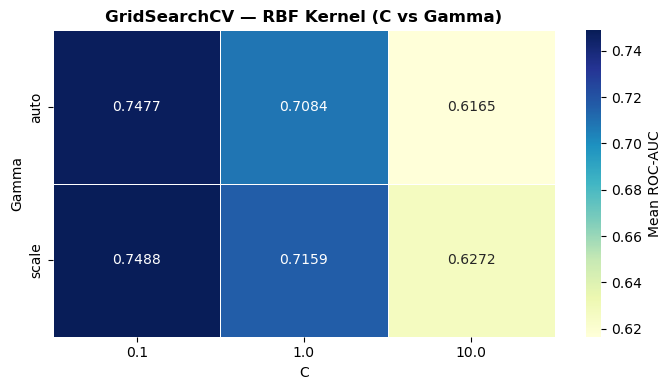

In [44]:
results_df = pd.DataFrame(grid.cv_results_)
rbf_res    = results_df[results_df['param_svm__kernel']=='rbf'][['param_svm__C','param_svm__gamma','mean_test_score']]
rbf_pivot  = rbf_res.pivot(index='param_svm__gamma', columns='param_svm__C', values='mean_test_score')

plt.figure(figsize=(7, 4))
sns.heatmap(rbf_pivot, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label':'Mean ROC-AUC'})
plt.title('GridSearchCV — RBF Kernel (C vs Gamma)', fontweight='bold')
plt.xlabel('C'); plt.ylabel('Gamma')
plt.tight_layout(); plt.show()